In [1]:
from nautilus import Prior, Sampler
import numpy as np
from scipy.stats import norm
from getdist import plots, MCSamples

import sys
sys.path.append('../')
from src import IO, load_config, redshift_distributions

# Load the Fisher Matrix

In [2]:
config = load_config('../configs/config_main_A_s.yaml')
fm = IO.load_fisher_matrix(config, 'fm_sampling_validation')

### Load the redshift error priors

In [3]:
N_z_bins = config.redshift_distributions.sources.N_z_bins
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)

# Load the Nautilus sampler
### Match the priors to the ones in the Nautilus run

In [4]:
filename = './testing_A_s.hdf5'

# Priors
prior = Prior()
for ip, p in enumerate(config.sampling_validation.keys()):
    if config.sampling_validation[p] is None:
        continue
    elif len(config.sampling_validation[p]) == 2:
        prior.add_parameter(p, dist=tuple(config.sampling_validation[p]))
    elif p=='delta_z':
        for i in range(N_z_bins):
            prior.add_parameter(f'dz_{i + 1}', dist=norm(loc=0.0,
                scale=config.redshift_distributions.sources.sigma_delta_z*(1 + mean_z[i])))
    else:
        raise ValueError(f'Input parameter in config file had problem: {p}')

sampler = Sampler(prior, lambda x: 1., filepath=filename)

In [5]:
points, log_w, log_l = sampler.posterior()
ndim = points.shape[1]

gd_samples_nautilus = MCSamples(samples=points,
                                 weights=np.exp(log_w),
                                 loglikes=log_l,
                                 names = fm.parameters,
                                 labels = [x.strip('$') for x in fm.latex_parameters],
                                 label='Nautilus',
                                 sampler='nested')

Removed no burn in


# Plot the posterior and the Fisher matrix

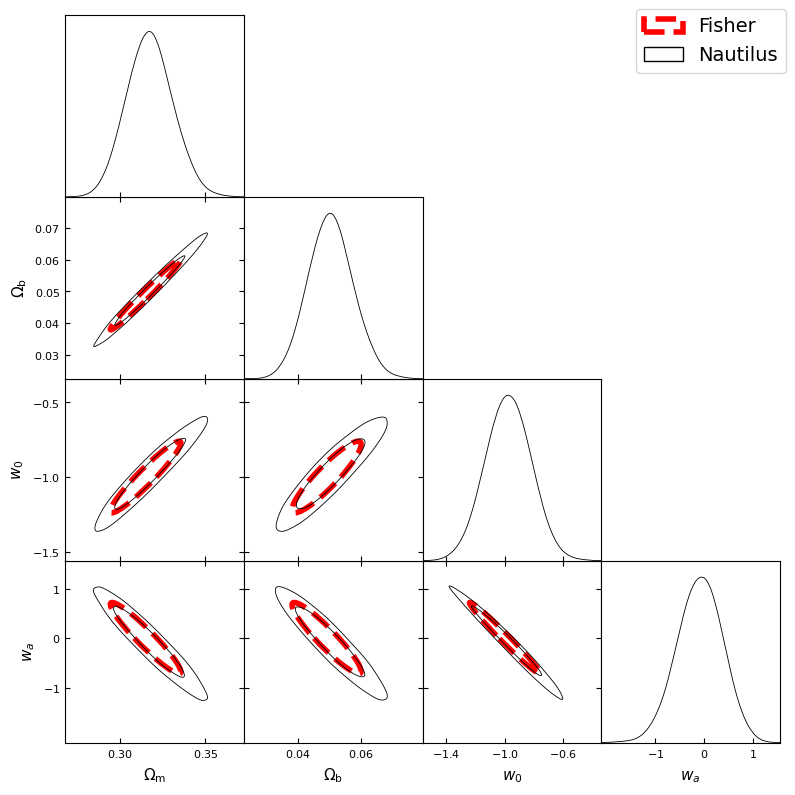

In [6]:
# Triangle plot
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gd_samples_nautilus])

for p2i in range(ndim): # row
    for p1i in range(p2i): # column
        ax = g.subplots[p2i, p1i]
        mu = [fm.fiducial_parameters[p1i], fm.fiducial_parameters[p2i]]
        ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, [fm.parameters[p1i], fm.parameters[p2i]],
            CL=0.68, color='r', fill=False, ls='--', label='Fisher', linewidth=4)

handles, legend_labels = ax.get_legend_handles_labels()
from matplotlib.patches import Patch
handles.append(Patch(facecolor='white', edgecolor='k'))
legend_labels.append('Nautilus')
g.fig.legend(handles, legend_labels, fontsize=14, loc='upper right')

# Debug land here ---

In [7]:
import os
# First thing, restrict to 1 CPU per thread for using MPI properly.
os.environ["OMP_NUM_THREADS"] = "1"

from nautilus import Prior, Sampler
from scipy.stats import norm #, multivariate_normal
import pyccl as ccl
from scipy.interpolate import interp1d
from itertools import pairwise
import argparse
import sys
sys.path.append('../')
from src import load_config, fisher_matrix, redshift_distributions, IO, fisher, names_to_latex
import numpy as np

print(f'Running fisher analysis for {config.name}.')
# Load the cosmology
ccl_cosmo_params = dict(zip(config.cosmology.keys(), config.cosmology.values()))
if 'Omega_m' in ccl_cosmo_params.keys():
    ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b']
    ccl_cosmo_params.pop('Omega_m')
cosmo = ccl.Cosmology(**ccl_cosmo_params,
                      matter_power_spectrum='camb',
                      extra_parameters={"camb": config.baryons_dict})

# ell binning setup
ell_bins = np.geomspace(config.ell_binning.cosmic_shear.bin_start,
                        config.ell_binning.cosmic_shear.bin_end,
                        config.ell_binning.cosmic_shear.N_bins+1)
ell_bins = ell_bins[
    (ell_bins >= config.ell_binning.cosmic_shear.ell_min) &
    (ell_bins <= config.ell_binning.cosmic_shear.ell_max)
    ].astype(int)
ell_arr = np.array([(a + b) / 2 for a, b in pairwise(ell_bins)]).astype(int)
Delta_ell = np.array([b - a for a, b in pairwise(ell_bins)])

# Define the forecasting setup
sigma_e = config.forecast.e_rms
N_z_bins = config.redshift_distributions.sources.N_z_bins
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))

# Define the fisher matrix setup
cosmo_params = {'name': list(config.cosmology.keys()),
                'fiducial': list(config.cosmology.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.cosmology.keys())],
                'latex': [names_to_latex(x) for x in config.cosmology.keys()]}
astro_params = {'name': list(config.IA.keys())+list(config.baryons.keys()),
                 'fiducial': list(config.IA.values())+list(config.baryons.values()),
                 'shift': [config.derivatives.step_size[x] for x in list(config.IA.keys())+list(config.baryons.keys())],
                 'latex': [names_to_latex(x) for x in list(config.IA.keys())+list(config.baryons.keys())]}
redshift_params = {'name': [f'dz{i+1}' for i in range(N_z_bins)],
                   'fiducial': [0.] * N_z_bins,
                   'shift': [config.derivatives.step_size.delta_z] * N_z_bins,
                   'latex': ['$\Delta z_{%i}$' % (i + 1) for i in range(N_z_bins)]}

# Compute the fisher matrix
print(f'Computing fisher matrix.')
fm = fisher_matrix(cosmo=cosmo, z=z_arr, dndz=nz_arr, ell=ell_arr,
                   sigma_e=sigma_e,
                   n_bar=config.redshift_distributions.sources.nbar,
                   fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                   n_points=config.derivatives.stencil_points, cosmo_params=cosmo_params,
                   astro_params=astro_params, redshift_params=redshift_params)

# Add Gaussian photo-z priors
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)
fm.add_prior(redshift_params['name'], scale_z)

#print(f'Writing output.')
#IO.save_fisher_matrix(config, fm, 'fm_sampling_validation')

# Compute the theory data and covariance
C_ell_vec = fm.C_ell
covariance_matrix = fm.data_covariance
data = np.array(list(C_ell_vec.values())).flatten()
N_ell = len(ell_arr)
N_tracer_combinations = len(C_ell_vec.keys())
cov = np.zeros((N_ell*N_tracer_combinations, N_ell*N_tracer_combinations))
for i in range(N_tracer_combinations):
    for j in range(N_tracer_combinations):
        cov[i*N_ell:(i+1)*N_ell, j*N_ell:(j+1)*N_ell] = np.diag(covariance_matrix[:, i, j])
invcov = np.linalg.inv(cov)

# Priors
prior = Prior()
for ip, p in enumerate(config.sampling_validation.keys()):
    if config.sampling_validation[p] is None:
        continue
    elif len(config.sampling_validation[p]) == 2:
        prior.add_parameter(p, dist=tuple(config.sampling_validation[p]))
    elif p == 'delta_z':
        for i in range(N_z_bins):
            prior.add_parameter(f'dz_{i + 1}', dist=norm(loc=0.0,
                scale=config.redshift_distributions.sources.sigma_delta_z*(1 + mean_z[i])))
    else:
        raise ValueError(f'Input sampling parameter in config file had problem: {p}.')


# Likelihood
def likelihood(param_dict):
    cosmo_in_dict = config.cosmology.copy()
    bayrons_dict_in = config.baryons_dict.copy()
    A_IA_in = fm.A_IA
    eta_in = fm.eta
    dndz_in = nz_arr

    for ip, p in enumerate(config.sampling_validation.keys()):
        if config.sampling_validation[p] is None:
            continue
        elif config.sampling_validation[p] is not None:
            if p in config.cosmology.keys():
                cosmo_in_dict[p] = 1.*param_dict[p]
            elif p == 'logT_AGN':
                bayrons_dict_in = {'kmax': 20, "halofit_version": "mead2020_feedback",
                                   "HMCode_logT_AGN": 1.*param_dict['logT_AGN']}
            elif p == 'A_IA':
                A_IA_in = 1.*param_dict['A_IA']
            elif p == 'eta':
                eta_in = 1.*param_dict['eta']
            elif p == 'delta_z':
                dndz_in = np.zeros(nz_arr.shape)
                for i in range(N_z_bins):
                    interp_dndz = interp1d(z_arr, nz_arr[i], bounds_error=False, fill_value=0)
                    dndz_in[i] = interp_dndz(z_arr + 1.*param_dict[f'dz_{i+1}'])
            else:
                raise ValueError(f'Input sampling parameter in config file had problem: {p}.')

    if cosmo_in_dict['w0']+cosmo_in_dict['wa'] > 0:
        return -np.inf
    if 'Omega_m' in cosmo_in_dict.keys():
        cosmo_in_dict['Omega_c'] = cosmo_in_dict['Omega_m'] - cosmo_in_dict['Omega_b']
        cosmo_in_dict.pop('Omega_m')
    try:
        bayrons_dict_in.update({"dark_energy_model": "ppf"})
        cosmo_in = ccl.Cosmology(**cosmo_in_dict,
                                 matter_power_spectrum='camb',
                                 extra_parameters={"camb": bayrons_dict_in})
        model = fisher.get_Cell_data_vector(cosmo_in, z_arr, dndz_in, A_IA_in, eta=eta_in, ell=ell_arr)
        model = np.array(list(model.values())).flatten()
        #return multivariate_normal.logpdf(model, mean=data, cov=cov)
        return -0.5 * np.dot(np.dot(data-model, invcov), data-model)
    except:
        print(f'Problem with parameters: {param_dict.values()}')
        return -np.inf


resume = True

n_live_points = 3000
f_live = 0.01

pool_type = None

sampler = Sampler(prior, likelihood,
                  filepath=filename, resume=resume,
                  n_live=n_live_points,
                  pool=pool_type)
#sampler.run(verbose=True, discard_exploration=True, f_live=f_live)

Running fisher analysis for testing_A_s.
Computing fisher matrix.


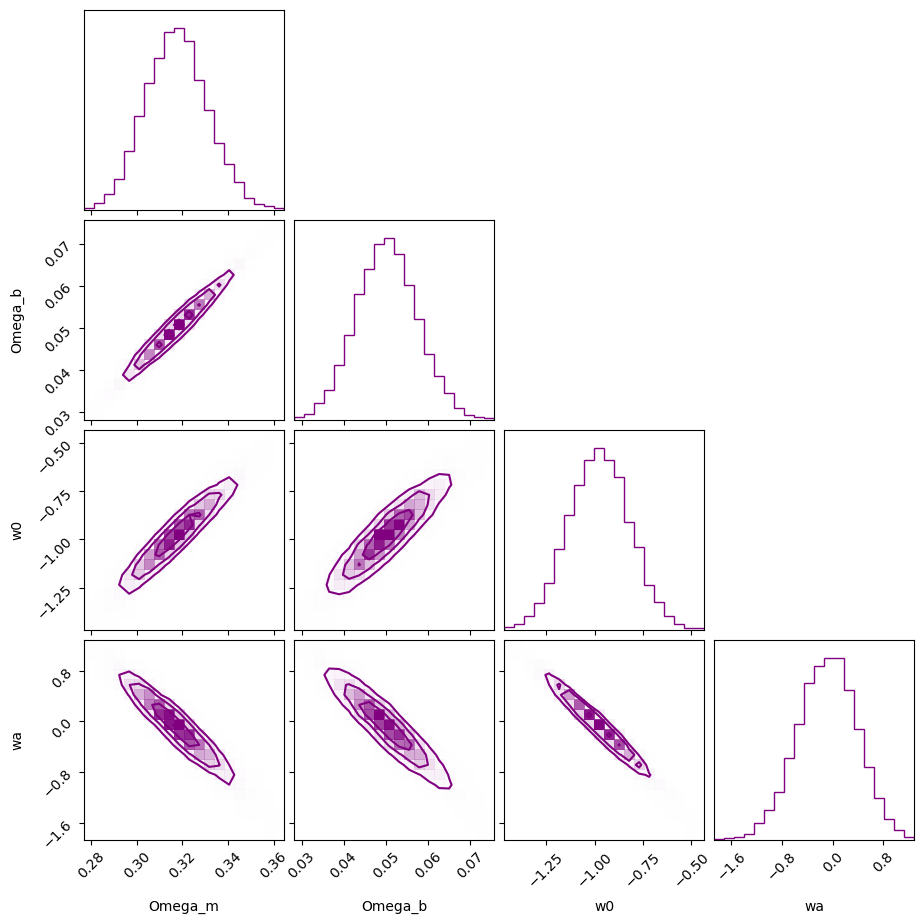

In [8]:
import corner
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=prior.keys, color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)));

Text(0, 0.5, 'Priors')

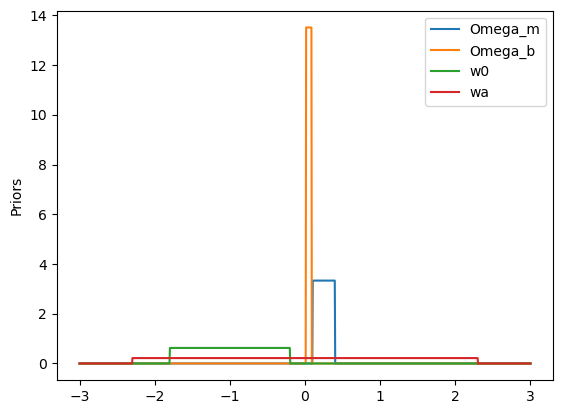

In [9]:
import matplotlib.pyplot as plt
x=np.linspace(-3,3,1024)
for i in range(prior.dimensionality()):
    plt.plot(x, prior.dists[i].pdf(x), label=f'{prior.keys[i]}')
    plt.legend()
plt.ylabel('Priors')

Text(0.5, 0, 'Weights')

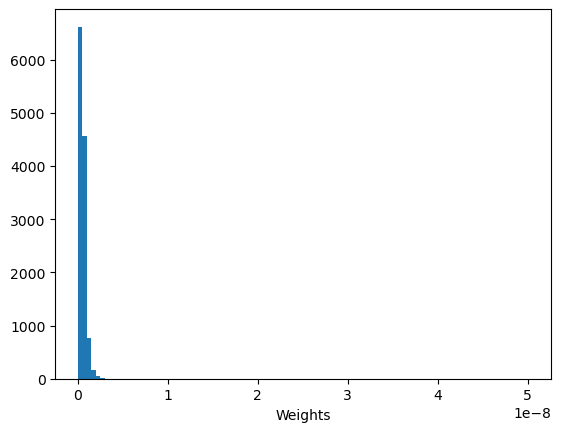

In [10]:
plt.hist(10**log_w, bins=100);
plt.xlabel('Weights')

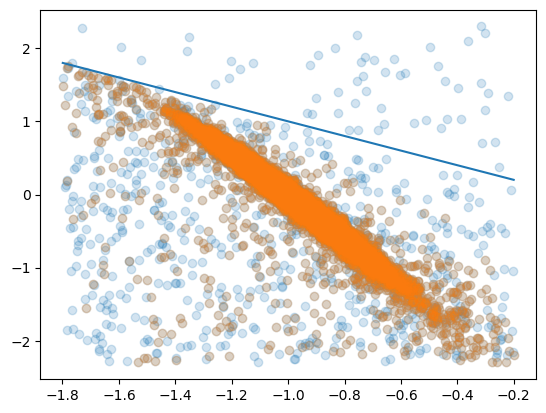

In [11]:
plt.scatter(points[:,2], points[:,3], alpha=0.2)
plt.scatter(points[:,2][10**log_w>0], points[:,3][10**log_w>0], alpha=0.2)

plt.plot([points[:,2:3].min(), points[:,2:3].max()], [-points[:,2:3].min(), -points[:,2:3].max()])

### Trying to find the maximum a posteriori here with a KDE grid search 
(2d example, need to extend to more)

In [12]:
from scipy import stats
m1, m2 = points[:,2], points[:,3]

xmin = m1.min()
xmax = m1.max()
ymin = m2.min()
ymax = m2.max()

X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]

positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([m1, m2])

kernel = stats.gaussian_kde(values)

Z = np.reshape(kernel(positions).T, X.shape)

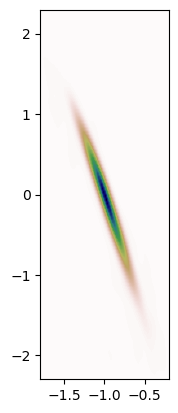

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
          extent=[xmin, xmax, ymin, ymax])
#ax.plot(m1, m2, 'k.', markersize=2)
#ax.set_xlim([xmin, xmax])
#ax.set_ylim([ymin, ymax])
plt.show()

In [14]:
no_samples = 10
xmin, ymin = np.min(values, axis=1)
xmax, ymax = np.max(values, axis=1)
x_samples = np.linspace(xmin, xmax, 1024)
y_samples = np.linspace(ymin, ymax, 1024)
samples = np.vstack([x_samples, y_samples])
probs = kernel.evaluate(samples)
maxima_index = probs.argmax()
maxima = x_samples[maxima_index]


In [15]:
x_samples[maxima_index], y_samples[maxima_index]

(-1.0005457271555114, -0.001923405442431747)

### Likelihood around fiducial values
to test that it's maximum where it should be.

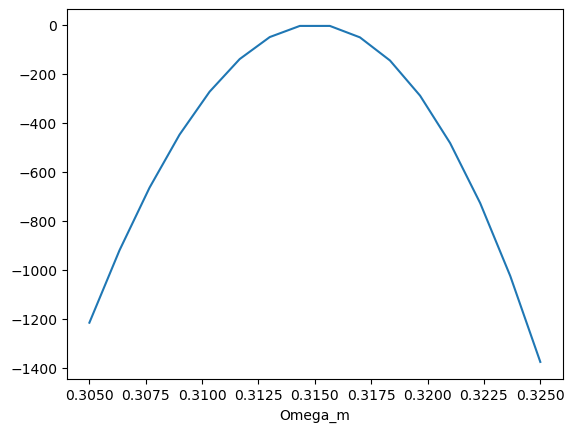

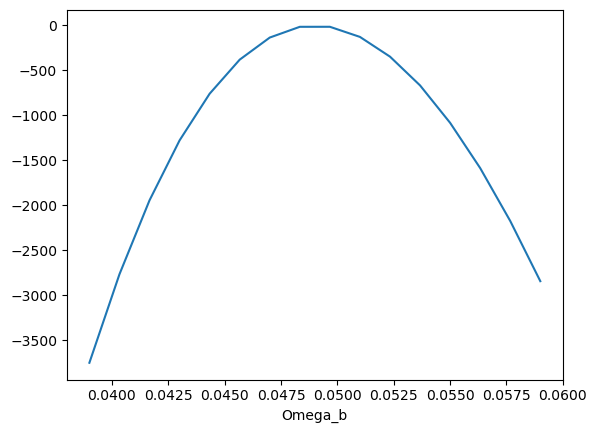

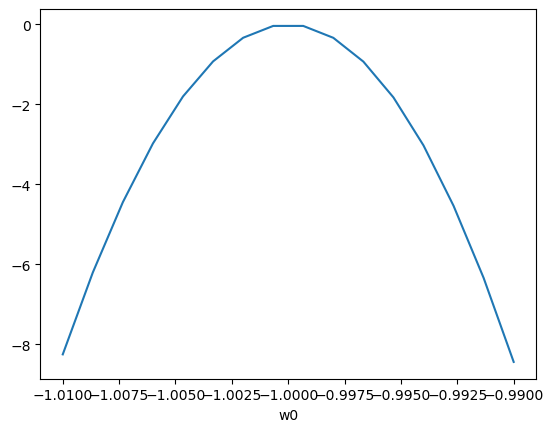

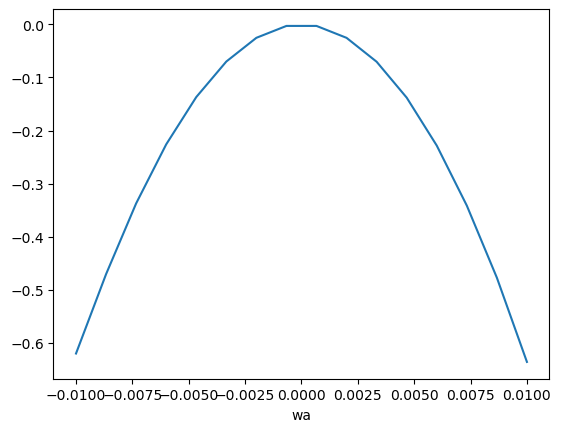

In [16]:
for ip, p in enumerate(fm.parameters):
    p_in = np.linspace(config.cosmology[p]-0.01, config.cosmology[p]+0.01, 16)
    log_l = np.zeros((len(fm.parameters), len(p_in)))
    param_in = dict(zip(fm.parameters, fm.fiducial_parameters))
    for ipv, p_value in enumerate(p_in):
        param_in[p] = p_value
        log_l[ip, ipv] = likelihood(param_in)
    plt.figure()
    plt.plot(p_in, log_l[ip], label=p)
    plt.xlabel(p)
    plt.show()